# Lab 3 · Hyperparameter optimisation — Guided notebook

**BME · MSc Deep Learning / VITMMA19 · Fall 2026/2027**  
Department of Telecommunications and Artificial Intelligence  
**Instructor:** Dr. Mohammed Salah Al-Radhi

**30 minutes, including setup.** Then complete the 60-minute assignment independently.

In Lab 2 you implemented a training loop and compared two learning rates. Today you will use that loop as an experimental tool: diagnose, search, record, confirm, and finally test.

By the end, you should be able to explain why learning rates use a log scale, distinguish early stopping from pruning, restore the selected checkpoint, and separate tuning from final testing.

| Minutes | Activity |
| --- | --- |
| 0–5 | Setup, data, and validation protocol |
| 5–12 | Diagnose and compare learning rates |
| 12–17 | Read the training engine and checkpoint logic |
| 17–27 | Optuna search, pruning, and the experiment log |
| 27–30 | Interpret results and introduce the assignment |

Save a copy in Drive. Use a **CPU runtime**; a GPU is unnecessary for these tiny models. The dataset ships with scikit-learn, so no image download or external account is needed. Only the first Optuna installation needs internet access.

## 1. Fix the experiment before trying settings

We use 1,797 handwritten digits, each represented by 64 pixels. The split is stratified, approximately 60% training, 20% validation, and 20% test. The fixed split is shared with the assignment: guided training never uses assignment test IDs.

Pixels are divided by the documented maximum, 16. This is a fixed conversion, so no statistics are learned from validation or test data. If we fitted a scaler, it would have to be fitted using training data only.

**Predict:** what should cross-entropy be for ten equally likely classes? Approximately `ln(10) = 2.303`. Accuracy would be around 10%, subject to class proportions.

We **minimise best validation cross-entropy (CE)**. Accuracy is a useful secondary metric. Test data stay closed throughout this guided notebook.

In [1]:
#@title Setup: install only the lab's tested Optuna version if needed
import importlib.metadata
import subprocess
import sys
try:
    optuna_version = importlib.metadata.version('optuna')
except importlib.metadata.PackageNotFoundError:
    optuna_version = None
if optuna_version != '4.7.0':
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'optuna==4.7.0'])
print("Optuna 4.7.0 is ready. Keep Colab's existing PyTorch/NumPy packages.")

Optuna 4.7.0 is ready. Keep Colab's existing PyTorch/NumPy packages.


In [2]:
import copy
import hashlib
import json
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
from sklearn.datasets import load_digits
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from IPython.display import display
import optuna

torch.set_num_threads(2)
DEVICE = torch.device('cpu')
SPLIT_SEED = 2026
SEARCH_SEED = 11
CONFIRM_SEEDS = [7, 17, 27]
MAX_EPOCHS = 25
BATCH_SIZE = 64
PATIENCE = 6
BASE_CONFIG = dict(lr=1e-5, hidden=64, dropout=0.0, weight_decay=1e-4)
RUNS = {}
TEST_OPENED = False
PHASE_LIMITS = dict(baseline=1, manual=3, optuna=8, refine=2, repeat=6)
optuna.logging.set_verbosity(optuna.logging.WARNING)


print('Python:', sys.version.split()[0])
print('PyTorch:', torch.__version__, '| Optuna:', optuna.__version__)
print('NumPy:', np.__version__, '| scikit-learn:', sklearn.__version__)
print('Device:', DEVICE, '| threads:', torch.get_num_threads())
print('Maximum epochs:', MAX_EPOCHS, '| batch size:', BATCH_SIZE, '| patience:', PATIENCE)

Python: 3.12.14
PyTorch: 2.8.0+cpu | Optuna: 4.7.0
NumPy: 2.5.3 | scikit-learn: 1.8.0
Device: cpu | threads: 2
Maximum epochs: 25 | batch size: 64 | patience: 6


In [3]:
#@title Provided data and split helpers — expand to inspect
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def prepare_data(noise_std):
    """Fixed stratified IDs; separate fixed noise draws; no test tensors returned."""
    digits = load_digits()
    ids = np.arange(len(digits.target))
    dev_ids, test_ids = train_test_split(
        ids, test_size=0.2, stratify=digits.target, random_state=SPLIT_SEED)
    train_ids, val_ids = train_test_split(
        dev_ids, test_size=0.25, stratify=digits.target[dev_ids],
        random_state=SPLIT_SEED)
    assert set(train_ids).isdisjoint(val_ids)
    assert set(train_ids).isdisjoint(test_ids)
    assert set(val_ids).isdisjoint(test_ids)

    def tensor_split(indices, noise_seed):
        # 16 is the documented pixel maximum, not an estimate from the data.
        clean = (digits.data[indices] / 16.0).astype(np.float32)
        noise = np.random.default_rng(noise_seed).normal(0, noise_std, clean.shape)
        values = np.clip(clean + noise, 0, 1).astype(np.float32)
        return torch.from_numpy(values), torch.tensor(digits.target[indices], dtype=torch.long)

    x_train, y_train = tensor_split(train_ids, 101)
    x_val, y_val = tensor_split(val_ids, 202)
    data = dict(x_train=x_train, y_train=y_train, x_val=x_val, y_val=y_val,
                train_ids=train_ids, val_ids=val_ids, noise_std=float(noise_std),
                sizes=(len(train_ids), len(val_ids), len(test_ids)))

    def final_test(run):
        """A teaching guard, not access security. Call after freezing the choice."""
        global TEST_OPENED
        if TEST_OPENED:
            raise RuntimeError('Test already opened. Reuse final_report; do not retune.')
        if run['status'] != 'complete':
            raise ValueError('Select a completed run with its best checkpoint restored.')
        TEST_OPENED = True
        xt, yt = tensor_split(test_ids, 303)
        metrics = evaluate(run['model'], xt, yt)
        with torch.no_grad():
            predictions = run['model'](xt).argmax(1)
        return dict(loss=metrics['loss'], accuracy=metrics['acc'], n=len(yt),
                    y_true=yt.numpy(), y_pred=predictions.numpy(), images=xt.numpy(),
                    run_name=run['name'], config=copy.deepcopy(run['config']), seed=run['seed'])

    return data, final_test

def show_training_images(data):
    fig, axes = plt.subplots(2, 5, figsize=(9, 3.6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(data['x_train'][i].reshape(8, 8), cmap='gray', vmin=0, vmax=1)
        ax.set_title(f"Label: {data['y_train'][i].item()}")
        ax.axis('off')
    fig.suptitle(f"Training images only | fixed noise standard deviation {data['noise_std']}")
    fig.tight_layout()
    plt.show()

Train / validation / held-out test: (1077, 360, 360)
Input shape: (1077, 64) | target dtype: torch.int64


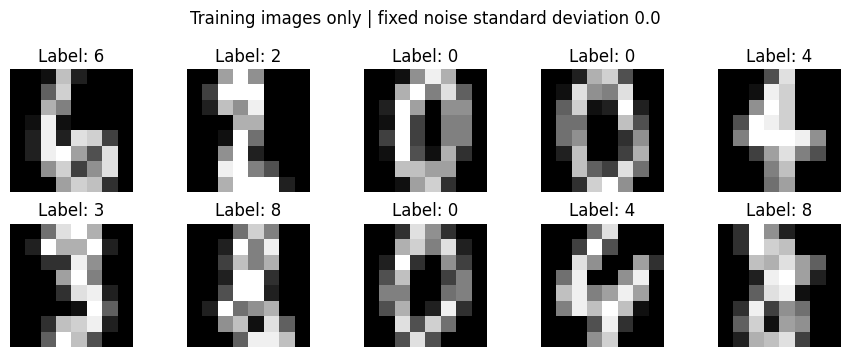

In [4]:
DATA, evaluate_final_test = prepare_data(noise_std=0.0)
print('Train / validation / held-out test:', DATA['sizes'])
print('Input shape:', tuple(DATA['x_train'].shape), '| target dtype:', DATA['y_train'].dtype)
show_training_images(DATA)

### Supplied experiment engine

The model is `64 → hidden → ReLU → dropout → 10 logits`; the maximum is **9,610 trainable parameters**. We use AdamW and cross-entropy. The engine:

1. Creates fresh model weights, optimizer state, and a seeded mini-batch order for every run.
2. Uses training data for gradients and validation loss to select an epoch.
3. Saves a **deep copy** of the best weights and restores it before returning.
4. Stops after 25 epochs, or six consecutive epochs with no lower validation loss. An Optuna pruner may stop a search trial earlier.
5. Logs every attempt, including pruned trials, to `lab3_experiments.csv`.

Training and validation curves are both measured at the end of each epoch in **evaluation mode**, with dropout off. This makes the two losses easier to compare. It adds a small evaluation cost.

The same seed gives the same initial weights when the architecture is unchanged. Different widths cannot share identical weight tensors. The split and mini-batch order still remain fixed. Seeds do not guarantee identical results across software versions or machines.

In [5]:
#@title Provided model, evaluation, training, and experiment log
def validate_config(config):
    assert set(config) == {'lr', 'hidden', 'dropout', 'weight_decay'}
    assert 1e-5 <= config['lr'] <= 0.1, 'Keep learning rate within the allowed range.'
    assert config['hidden'] in [32, 64, 128]
    assert 0 <= config['dropout'] <= 0.5
    assert 1e-6 <= config['weight_decay'] <= 0.1

def config_key(config):
    return json.dumps(config, sort_keys=True)

def make_model(config):
    return nn.Sequential(nn.Linear(64, config['hidden']), nn.ReLU(),
                         nn.Dropout(config['dropout']), nn.Linear(config['hidden'], 10))

@torch.no_grad()
def evaluate(model, x, y):
    model.eval()
    logits = model(x)
    return {'loss': nn.functional.cross_entropy(logits, y).item(),
            'acc': (logits.argmax(1) == y).float().mean().item()}

def run_experiment(config, name, phase, seed=SEARCH_SEED, trial=None, verbose=True):
    """Fresh model/optimizer/shuffle; validation-loss selection; no test access."""
    if TEST_OPENED:
        raise RuntimeError('The test has been opened. No more tuning in this experiment.')
    validate_config(config)
    if phase not in PHASE_LIMITS:
        raise ValueError('Use one of the specified experiment phases.')
    signature = (config_key(config), int(seed), phase, MAX_EPOCHS, PATIENCE, BATCH_SIZE)
    if name in RUNS:
        run = RUNS[name]
        if run['signature'] != signature:
            raise ValueError('This name already records another experiment. Use a remaining '
                             'refinement slot, or restart to reproduce the complete plan.')
        if run['status'] == 'pruned':
            raise optuna.TrialPruned()
        if run['status'] == 'failed':
            raise FloatingPointError('This run previously failed; inspect its recorded metrics.')
        if verbose:
            print(f'{name}: reusing the recorded run; no extra training.')
        return run
    used = sum(r['phase'] == phase for r in RUNS.values())
    if used >= PHASE_LIMITS[phase]:
        raise ValueError(f'The {phase} budget ({PHASE_LIMITS[phase]} runs) is used.')
    set_seed(seed)
    model = make_model(config)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                 weight_decay=config['weight_decay'])
    generator = torch.Generator().manual_seed(seed + 1000)
    x, y = DATA['x_train'], DATA['y_train']
    history, best_state = [], None
    best_loss, best_epoch, stale, updates = float('inf'), 0, 0, 0
    status, stop_reason = 'complete', 'epoch budget'
    start = time.perf_counter()
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        indices = torch.randperm(len(y), generator=generator)
        for batch_ids in indices.split(BATCH_SIZE):
            optimizer.zero_grad(set_to_none=True)
            loss = nn.functional.cross_entropy(model(x[batch_ids]), y[batch_ids])
            if not torch.isfinite(loss):
                status, stop_reason = 'failed', 'non-finite training loss'
                break
            loss.backward()
            optimizer.step()
            updates += 1
        train = evaluate(model, x, y)
        val = evaluate(model, DATA['x_val'], DATA['y_val'])
        history.append(dict(epoch=epoch, train_loss=train['loss'], train_acc=train['acc'],
                            val_loss=val['loss'], val_acc=val['acc']))
        if status == 'failed' or not np.isfinite(list(train.values()) + list(val.values())).all():
            status, stop_reason = 'failed', 'non-finite metric'
            break
        # Keep a genuine copy. state_dict() alone contains references to live tensors.
        if val['loss'] < best_loss:
            best_loss, best_epoch, stale = val['loss'], epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            stale += 1
        if trial is not None:
            trial.report(val['loss'], step=epoch)
            if trial.should_prune():
                status, stop_reason = 'pruned', 'median pruner'
                break
        if stale >= PATIENCE:
            stop_reason = f'early stopping: {PATIENCE} epochs without a new minimum'
            break
    if best_state is not None:
        model.load_state_dict(best_state)
        restored = evaluate(model, DATA['x_val'], DATA['y_val'])
        assert abs(restored['loss'] - best_loss) < 1e-6
    else:
        restored = {'loss': float('inf'), 'acc': float('nan')}
    result = dict(name=name, phase=phase, config=copy.deepcopy(config), seed=int(seed),
                  model=model, history=pd.DataFrame(history), status=status,
                  stop_reason=stop_reason, best_epoch=best_epoch,
                  best_val_loss=restored['loss'], best_val_acc=restored['acc'],
                  epochs_run=len(history), updates=updates,
                  parameters=sum(p.numel() for p in model.parameters()),
                  seconds=time.perf_counter() - start, signature=signature)
    RUNS[name] = result
    experiment_table().to_csv('lab3_experiments.csv', index=False)
    if trial is not None:
        for key in ['name', 'best_epoch', 'epochs_run', 'updates', 'best_val_acc', 'stop_reason']:
            trial.set_user_attr(key, result[key])
    if verbose:
        print(f"{name}: {status}; best validation CE {result['best_val_loss']:.4f}; "
              f"accuracy {result['best_val_acc']:.3f}; epoch {best_epoch}/{len(history)}; "
              f"{result['seconds']:.2f} s")
    if status == 'pruned':
        raise optuna.TrialPruned()
    if status == 'failed':
        raise FloatingPointError(stop_reason)
    return result

def experiment_table():
    rows = []
    for r in RUNS.values():
        keys = ['name', 'phase', 'seed', 'status', 'best_val_loss', 'best_val_acc',
                'best_epoch', 'epochs_run', 'updates', 'parameters', 'seconds', 'stop_reason']
        rows.append({**{k: r[k] for k in keys}, **r['config']})
    return pd.DataFrame(rows)

In [6]:
#@title Provided plotting helpers
def plot_curves(runs, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    for run in runs:
        h = run['history']
        line, = axes[0].plot(h.epoch, h.val_loss, label=run['name'] + ' validation')
        axes[0].plot(h.epoch, h.train_loss, '--', color=line.get_color(), alpha=.65)
        axes[1].plot(h.epoch, h.val_acc, label=run['name'])
        axes[0].scatter(run['best_epoch'], run['best_val_loss'], color=line.get_color(), s=25)
    axes[0].set(xlabel='Epoch', ylabel='Cross-entropy', title='Solid: validation | dashed: training')
    axes[1].set(xlabel='Epoch', ylabel='Validation accuracy', ylim=(0, 1.02))
    for ax in axes:
        ax.grid(alpha=.2)
        ax.legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

def plot_search(study):
    trials = study.trials_dataframe()
    complete = trials[trials.state == 'COMPLETE'].copy()
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
    if len(complete):
        axes[0].scatter(complete.number, complete.value, label='Completed trial')
        axes[0].plot(complete.number, complete.value.cummin(), label='Best so far')
        axes[1].scatter(complete.params_lr, complete.value)
        axes[1].set_xscale('log')
    axes[0].set(xlabel='Trial number', ylabel='Best validation CE')
    axes[1].set(xlabel='Learning rate (log scale)', ylabel='Best validation CE')
    axes[0].legend()
    for ax in axes: ax.grid(alpha=.2)
    fig.tight_layout()
    plt.show()
    print('Only COMPLETE trials are ranked here. PRUNED trials remain in the experiment log.')

def show_test_report(report):
    print(f"Selected run: {report['run_name']} | test n={report['n']} | "
          f"CE={report['loss']:.4f} | accuracy={report['accuracy']:.3f}")
    cm = confusion_matrix(report['y_true'], report['y_pred'], labels=np.arange(10))
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=np.arange(10)).plot(ax=ax, colorbar=False)
    ax.set_title('Held-out test digits | rows=true, columns=predicted')
    fig.tight_layout()
    plt.show()
    errors = np.flatnonzero(report['y_true'] != report['y_pred'])[:6]
    if len(errors):
        fig, axes = plt.subplots(1, len(errors), figsize=(2 * len(errors), 2.3), squeeze=False)
        for ax, idx in zip(axes.flat, errors):
            ax.imshow(report['images'][idx].reshape(8, 8), cmap='gray', vmin=0, vmax=1)
            ax.set_title(f"True {report['y_true'][idx]} / pred {report['y_pred'][idx]}", fontsize=9)
            ax.axis('off')
        fig.tight_layout()
        plt.show()
    else:
        print('No mistakes in this test split.')

## 2. One variable at a time · minutes 5–12

All three runs use the same architecture, seed, batch size, maximum epochs, early-stopping rule, and optimizer. Only learning rate changes.

**Before running:** which rate might barely learn? Which might move quickly but become unstable? Record the prediction orally before showing results. A high rate does not fail on every problem.

Guided_LR_1: complete; best validation CE 2.2519; accuracy 0.239; epoch 25/25; 0.21 s
Guided_LR_2: complete; best validation CE 0.0990; accuracy 0.978; epoch 25/25; 0.23 s
Guided_LR_3: complete; best validation CE 0.1124; accuracy 0.964; epoch 7/13; 0.13 s


,name,lr,best_val_loss,best_val_acc,best_epoch,epochs_run
0,Guided_LR_1,0.00001,2.251855,0.238889,25,25
1,Guided_LR_2,0.00300,0.099018,0.977778,25,25
2,Guided_LR_3,0.10000,0.112381,0.963889,7,13


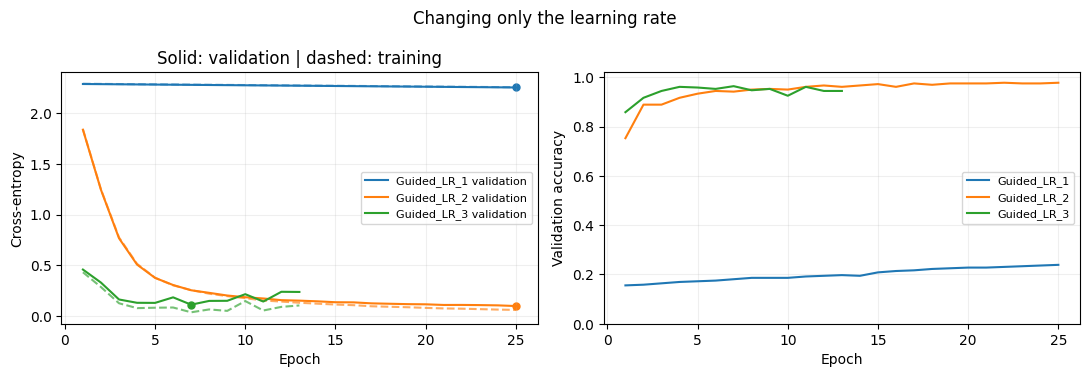

In [7]:
guided_lrs = [1e-5, 3e-3, 1e-1]
guided_runs = [run_experiment({**BASE_CONFIG, 'lr': lr}, name=f'Guided_LR_{i+1}', phase='manual')
               for i, lr in enumerate(guided_lrs)]
display(experiment_table()[['name', 'lr', 'best_val_loss', 'best_val_acc', 'best_epoch', 'epochs_run']])
plot_curves(guided_runs, 'Changing only the learning rate')

## 3. Explain the evidence · minutes 12–17

- A nearly flat high training loss can indicate insufficient optimisation; it does not automatically mean the network is too small.
- A widening training–validation gap can motivate regularisation. It is not a numerical measurement of the theoretical variance term.
- The reported validation accuracy is measured at the **minimum-validation-loss checkpoint**, not necessarily the maximum-accuracy epoch.
- **Early stopping** compares a run with its own past validation losses. **Pruning** compares partial search-trial evidence with other trials. Either can miss a late improvement.

Expand `run_experiment` and locate `copy.deepcopy`, `load_state_dict`, `trial.report`, and `trial.should_prune`. The saved weights must match the reported score.

## 4. A small automated search · minutes 17–27

`lr` and `weight_decay` span orders of magnitude, so sample them logarithmically. Width is categorical; dropout is sampled linearly.

TPE (Tree-structured Parzen Estimator) uses completed observations to propose settings. We explicitly use four startup trials; a short study with the default startup count can spend its entire budget sampling randomly. Eight trials illustrate the workflow, not a reliable ranking of search algorithms.

Our median pruner waits for three completed trials and cannot prune before epoch 5. Pruning is a heuristic; **zero pruned trials is a valid outcome**.

Guided_TPE_00: complete; best validation CE 0.3491; accuracy 0.942; epoch 25/25; 0.25 s
Guided_TPE_01: complete; best validation CE 1.8925; accuracy 0.608; epoch 25/25; 0.24 s
Guided_TPE_02: complete; best validation CE 0.1023; accuracy 0.975; epoch 14/20; 0.19 s
Guided_TPE_03: complete; best validation CE 0.1587; accuracy 0.969; epoch 25/25; 0.28 s
Guided_TPE_04: complete; best validation CE 0.0715; accuracy 0.975; epoch 10/16; 0.25 s
Guided_TPE_05: complete; best validation CE 0.0716; accuracy 0.975; epoch 11/17; 0.24 s
Guided_TPE_06: complete; best validation CE 0.0749; accuracy 0.981; epoch 21/25; 0.34 s
Guided_TPE_07: pruned; best validation CE 0.1812; accuracy 0.944; epoch 5/5; 0.07 s
Best parameters: {'lr': 0.04360959649429809, 'hidden': 128, 'dropout': 0.3198060649701772, 'weight_decay': 0.0004842565005159426}
Only COMPLETE trials are ranked here. PRUNED trials remain in the experiment log.


,number,state,value,params_lr,params_hidden,params_dropout,params_weight_decay
0,0,COMPLETE,0.349104,0.001025,32,0.062407,0.000004
1,1,COMPLETE,1.892464,0.000143,32,0.008234,0.007579
2,2,COMPLETE,0.102308,0.017650,32,0.121697,0.000126
3,3,COMPLETE,0.158672,0.001465,64,0.116858,0.000029
4,4,COMPLETE,0.071501,0.043610,128,0.319806,0.000484
5,5,COMPLETE,0.071641,0.045236,128,0.356515,0.002155
6,6,COMPLETE,0.074893,0.010229,128,0.325882,0.000391
7,7,PRUNED,0.181219,0.006549,128,0.251390,0.000630


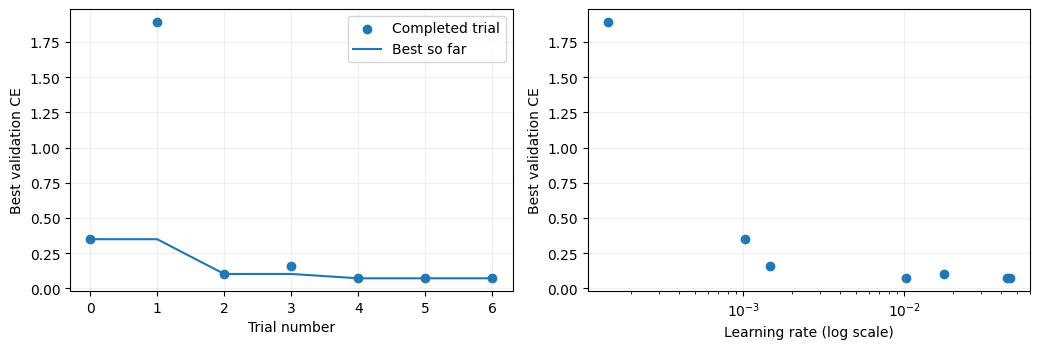

In [8]:
def guided_objective(trial):
    config = dict(
        lr=trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        hidden=trial.suggest_categorical('hidden', [32, 64, 128]),
        dropout=trial.suggest_float('dropout', 0.0, 0.4),
        weight_decay=trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True))
    run = run_experiment(config, f'Guided_TPE_{trial.number:02d}', 'optuna', trial=trial)
    return run['best_val_loss']

if 'guided_study' not in globals():
    guided_study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=4),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=5))
guided_study.optimize(guided_objective, n_trials=max(0, 8-len(guided_study.trials)),
                     n_jobs=1, catch=(FloatingPointError,))
print('Best parameters:', guided_study.best_params)
display(guided_study.trials_dataframe()[['number', 'state', 'value', 'params_lr',
                                        'params_hidden', 'params_dropout', 'params_weight_decay']])
plot_search(guided_study)

In [9]:
log = experiment_table()
search_log = log[log.phase == 'optuna']
print('Completed / pruned / failed:')
print(search_log.status.value_counts())
print('Epochs actually run:', int(search_log.epochs_run.sum()))
print('Upper bound without any early exit:', 8 * MAX_EPOCHS)
print('Recorded training/evaluation seconds:', round(search_log.seconds.sum(), 2))
display(log[['name', 'status', 'best_val_loss', 'best_val_acc', 'epochs_run', 'updates', 'parameters']])

Completed / pruned / failed:
status
complete    7
pruned      1
Name: count, dtype: int64
Epochs actually run: 158
Upper bound without any early exit: 200
Recorded training/evaluation seconds: 1.87


,name,status,best_val_loss,best_val_acc,epochs_run,updates,parameters
0,Guided_LR_1,complete,2.251855,0.238889,25,425,4810
1,Guided_LR_2,complete,0.099018,0.977778,25,425,4810
2,Guided_LR_3,complete,0.112381,0.963889,13,221,4810
3,Guided_TPE_00,complete,0.349104,0.941667,25,425,2410
4,Guided_TPE_01,complete,1.892464,0.608333,25,425,2410
5,Guided_TPE_02,complete,0.102308,0.975000,20,340,2410
6,Guided_TPE_03,complete,0.158672,0.969444,25,425,4810
7,Guided_TPE_04,complete,0.071501,0.975000,16,272,9610
8,Guided_TPE_05,complete,0.071641,0.975000,17,289,9610
9,Guided_TPE_06,complete,0.074893,0.980556,25,425,9610


## 5. What can we conclude? · minutes 27–30

The difference from `8 × 25` is **unused epoch allocation**. It is not proof of a pruning-only speedup: our driver also early-stops, and different widths cost different amounts per epoch. A causal pruning comparison would need a matched no-pruning experiment.

The best trial is only a candidate. We repeatedly queried the same small validation set, so its best score can be optimistic. Confirm promising configurations with fixed additional seeds, and keep the test set closed until the choice is frozen. Three seeds measure training randomness on this split; they are not three new datasets.

**Assignment challenge:** the same digit IDs now have fixed Gaussian pixel noise. Copying the guided settings may be a useful start, but you must diagnose, search, refine, compare two finalists over three seeds, and justify a final decision.

We stop the guided notebook here without evaluating test data. Start the assignment now.

## Optional after class · Weights & Biases

The lecture also introduced W&B. The required lab uses the visible table and CSV log, so no W&B account or API key is needed. If you want to explore W&B later, its offline mode can record the same metrics locally. The optional cell is off by default and does not upload data. Online dashboards/sync are a separate choice; never upload student identifiers or private data without authorisation.

This section is **not part of the 30-minute guided session or grading**.

In [10]:
RUN_OPTIONAL_WANDB = False
if RUN_OPTIONAL_WANDB:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'wandb'])
    import wandb
    with wandb.init(project='bme-dl-lab03', mode='offline', config={'max_epochs': MAX_EPOCHS}) as wb:
        for record in experiment_table().to_dict('records'):
            wb.log({'validation_ce': record['best_val_loss'],
                    'validation_accuracy': record['best_val_acc'],
                    'epochs_run': record['epochs_run'], 'lr': record['lr']})
else:
    print('Optional W&B logging skipped. The required CSV/table log is already available.')

Optional W&B logging skipped. The required CSV/table log is already available.


## References and credits

- [scikit-learn: the 8×8 digits dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html), derived from UCI Optical Recognition of Handwritten Digits, C. Kaynak. This is **not MNIST**.
- [PyTorch: AdamW](https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html), [saving best-model copies](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html), and [reproducibility](https://docs.pytorch.org/docs/stable/notes/randomness.html).
- [Optuna: search and pruning](https://optuna.readthedocs.io/en/v4.7.0/tutorial/10_key_features/003_efficient_optimization_algorithms.html), [TPE sampler](https://optuna.readthedocs.io/en/v4.7.0/reference/samplers/generated/optuna.samplers.TPESampler.html), and [median pruner](https://optuna.readthedocs.io/en/v4.7.0/reference/generated/optuna.pruners.MedianPruner.html).
- Bergstra & Bengio, [Random Search for Hyper-Parameter Optimization](https://www.jmlr.org/papers/v13/bergstra12a.html), JMLR, 2012.
- BME lecture: *Deep Learning — Hyperparameter Optimization* (29 September 2026), supplied course slides.

Course material: Dr. Mohammed Salah Al-Radhi, BME. Dataset and framework credits remain with their authors. The added noise is an artificial classroom transformation, not a new benchmark dataset.